# Bienvenue dans Colab !

# 🎨 Classificazione Stagioni — CelebA

## Struttura del progetto
**PARTE 1** → 4 stagioni : `autunno` · `estate` · `inverno` · `primavera`  
**PARTE 2** → 12 sotto-tipi (**un solo modello**) : `autunno_deep`, …, `primavera_warm`

> Ogni esperimento è eseguito **due volte** :  
> **🅐 Tutti i dati** (cartella Drive completa — `RGB/train` e `RGB/test`)  
> **🅑 No-Makeup only** (stessi train/test set della sezione A, filtrati tramite CSV)

---
## Ordine di esecuzione
```
Passo 0  → Installazione
Passo 1  → Imports & iperparametri
Passo 2  → Google Drive & percorsi   ← unica differenza tra 🅐 e 🅑
Passo 3  → Trasformazioni
Passo 4  → Funzioni condivise
── 🅐 TUTTI I DATI ──────────────────────────────────────────
Passo 5A → PARTE 1 · 4 stagioni       (tutti i dati)
Passo 6A → PARTE 2 · 12 sotto-tipi   (tutti i dati)
── 🅑 NO-MAKEUP ONLY ───────────────────────────────────────
Passo 5B → PARTE 1 · 4 stagioni       (no-makeup — stesso split, filtro CSV)
Passo 6B → PARTE 2 · 12 sotto-tipi   (no-makeup — stesso split, filtro CSV)
── FINE ────────────────────────────────────────────────────
Passo 7  → Riepilogo comparativo
```


## Passo 0 — Installazione

In [14]:
!pip install -q torch torchvision scikit-learn seaborn
print("✅ Librerie installate.")


✅ Librerie installate.


In [15]:
# TEST VELOCE SU CPU — rimuovere prima del training vero
#EPOCHS     = 2
#BATCH_SIZE = 16

## Passo 1 — Imports & iperparametri

In [16]:
import os, copy
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, accuracy_score,
)

import torch
import torch.nn           as nn
import torch.optim        as optim
from torch.utils.data     import Dataset, DataLoader
from torchvision          import transforms, models
from torchvision.datasets import ImageFolder

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEM    = torch.cuda.is_available()
NUM_WORKERS = 2
print("Device :", device)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

# ── Iperparametri ─────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30      # max ; early stopping si fermerà prima
LR         = 1e-4
PATIENCE   = 5       # epoche senza miglioramento val_loss → stop


Device : cuda
GPU    : Tesla T4


## Passo 2 — Google Drive & percorsi

In [17]:
from google.colab import drive
drive.mount('/content/drive')

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ⚙️  MODIFICARE I PERCORSI QUI SE NECESSARIO                           ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║                                                                          ║
# ║  🅐  TUTTI I DATI                                                       ║
TRAIN_ALL  = "/content/drive/MyDrive/progetto/RGB/ORIGINAL_RGB_NOT_PROCESSED/ORIGINAL_RGB_NOT_PROCESSED/train"
TEST_ALL   = "/content/drive/MyDrive/progetto/RGB/ORIGINAL_RGB_NOT_PROCESSED/ORIGINAL_RGB_NOT_PROCESSED/test"
OUTPUT_ALL = "/content/drive/MyDrive/progetto/risultati_all"
# ║                                                                          ║
# ║  🅑  NO-MAKEUP — stesso TRAIN_ALL/TEST_ALL, filtrati via CSV            ║
# ║  Caricare su Drive il file filtered_no_makeup.csv                       ║
CSV_NM     = "/content/drive/MyDrive/progetto/filtered_no_makeup.csv"
OUTPUT_NM  = "/content/drive/MyDrive/progetto/risultati_nomakeup"
# ║                                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

os.makedirs(OUTPUT_ALL, exist_ok=True)
os.makedirs(OUTPUT_NM,  exist_ok=True)

# ── Costruzione dei set di filename no-makeup per train e test ────────────
# Il CSV contiene la colonna 'path_rgb_original' con percorsi del tipo:
#   RGB/train/autunno/deep/10306.jpg
# Il basename ('10306.jpg') corrisponde esattamente al nome del file su Drive.
# Usiamo basename come chiave univoca (verificato: 1872 valori tutti distinti).


# Usiamo la colonna 'filename' invece di basename da path_rgb_original
# perché i file su Drive hanno il nome con zero iniziale (010306.jpg)
df_nm = pd.read_csv(CSV_NM)

def normalizza_nome(nome):
    """Rimuove zeri iniziali e cambia estensione in .png"""
    senza_ext = os.path.splitext(nome)[0]   # '010306'
    numero    = str(int(senza_ext))          # '10306' — rimuove zeri
    return numero + '.png'                   # '10306.png'

NM_TRAIN = set(
    df_nm[df_nm['partition'] == 'train']['filename']
    .apply(normalizza_nome)
)
NM_TEST = set(
    df_nm[df_nm['partition'] == 'test']['filename']
    .apply(normalizza_nome)
)

print(f"  ✅ NM_TRAIN : {len(NM_TRAIN)} immagini no-makeup nel train set")
print(f"  ✅ NM_TEST  : {len(NM_TEST)}  immagini no-makeup nel test set")
print("\nEsempi NM_TRAIN:", list(NM_TRAIN)[:5])
print("Esempi NM_TEST: ", list(NM_TEST)[:5])

# Verifica match con file reali su Drive
match = sum(1 for f in list(NM_TRAIN)[:50] if any(
    f in os.listdir(os.path.join(TRAIN_ALL, s, st))
    for s in os.listdir(TRAIN_ALL) if os.path.isdir(os.path.join(TRAIN_ALL, s))
    for st in os.listdir(os.path.join(TRAIN_ALL, s)) if os.path.isdir(os.path.join(TRAIN_ALL, s, st))
))
print(f"\nMatch sui primi 50: {match}/50")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ NM_TRAIN : 1284 immagini no-makeup nel train set
  ✅ NM_TEST  : 588  immagini no-makeup nel test set

Esempi NM_TRAIN: ['948.png', '28302.png', '14305.png', '9757.png', '24975.png']
Esempi NM_TEST:  ['4306.png', '4513.png', '17537.png', '28418.png', '25428.png']

Match sui primi 50: 50/50


In [18]:
import os #explication per capire il strura del cartella

print("=" * 60)
print("DIAGNOSI STRUTTURA CARTELLE")
print("=" * 60)

print(f"\n📁 TRAIN_ALL: {TRAIN_ALL}")
for stagione in sorted(os.listdir(TRAIN_ALL)):
    s_path = f"{TRAIN_ALL}/{stagione}"
    if not os.path.isdir(s_path):
        continue
    contenuto = [x for x in os.listdir(s_path) if os.path.isdir(f"{s_path}/{x}")]
    if contenuto:
        # Ha sottocartelle → struttura a 3 livelli
        print(f"  📂 {stagione}/ → sottocartelle: {contenuto}")
        # Conta file in ogni sottocartella
        for sub in contenuto:
            n = len([f for f in os.listdir(f"{s_path}/{sub}")
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f"       📂 {sub}/ → {n} immagini")
    else:
        # File diretti → struttura a 2 livelli
        n = len([f for f in os.listdir(s_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  📂 {stagione}/ → {n} immagini (nessuna sottocartella)")

print(f"\n📁 TEST_ALL: {TEST_ALL}")
for stagione in sorted(os.listdir(TEST_ALL)):
    s_path = f"{TEST_ALL}/{stagione}"
    if not os.path.isdir(s_path):
        continue
    contenuto = [x for x in os.listdir(s_path) if os.path.isdir(f"{s_path}/{x}")]
    if contenuto:
        print(f"  📂 {stagione}/ → sottocartelle: {contenuto}")
    else:
        n = len([f for f in os.listdir(s_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  📂 {stagione}/ → {n} immagini")

DIAGNOSI STRUTTURA CARTELLE

📁 TRAIN_ALL: /content/drive/MyDrive/progetto/RGB/ORIGINAL_RGB_NOT_PROCESSED/ORIGINAL_RGB_NOT_PROCESSED/train
  📂 autunno/ → sottocartelle: ['warm', 'soft', 'deep']
       📂 warm/ → 283 immagini
       📂 soft/ → 318 immagini
       📂 deep/ → 446 immagini
  📂 estate/ → sottocartelle: ['soft', 'cool', 'light']
       📂 soft/ → 364 immagini
       📂 cool/ → 276 immagini
       📂 light/ → 312 immagini
  📂 inverno/ → sottocartelle: ['cool', 'bright', 'deep']
       📂 cool/ → 345 immagini
       📂 bright/ → 271 immagini
       📂 deep/ → 437 immagini
  📂 primavera/ → sottocartelle: ['warm', 'bright', 'light']
       📂 warm/ → 356 immagini
       📂 bright/ → 291 immagini
       📂 light/ → 331 immagini

📁 TEST_ALL: /content/drive/MyDrive/progetto/RGB/ORIGINAL_RGB_NOT_PROCESSED/ORIGINAL_RGB_NOT_PROCESSED/test
  📂 autunno/ → sottocartelle: ['warm', 'soft', 'deep']
  📂 estate/ → sottocartelle: ['light', 'soft', 'cool']
  📂 inverno/ → sottocartelle: ['deep', 'cool', 'bri

In [19]:
print("ANALISI DATASET COMPLETO")
print("=" * 60)

totale_num = 0
totale_cel = 0

for stagione in sorted(os.listdir(TRAIN_ALL)):
    s_path = os.path.join(TRAIN_ALL, stagione)
    if not os.path.isdir(s_path): continue
    print(f"\n📂 {stagione}")
    for sotto in sorted(os.listdir(s_path)):
        t_path = os.path.join(s_path, sotto)
        if not os.path.isdir(t_path): continue
        num = 0
        cel = 0
        for fn in os.listdir(t_path):
            if not fn.lower().endswith(('.jpg','.jpeg','.png')): continue
            if os.path.splitext(fn)[0].isdigit():
                num += 1
            else:
                cel += 1
        totale_num += num
        totale_cel += cel
        print(f"  {sotto:<10} → CelebA: {num:>4}  Celebrity: {cel:>4}")

print(f"\nTOTALE CelebA    : {totale_num}")
print(f"TOTALE Celebrity : {totale_cel}")

ANALISI DATASET COMPLETO

📂 autunno
  deep       → CelebA:  239  Celebrity:  207
  soft       → CelebA:  170  Celebrity:  148
  warm       → CelebA:  159  Celebrity:  124

📂 estate
  cool       → CelebA:  152  Celebrity:  124
  light      → CelebA:  151  Celebrity:  161
  soft       → CelebA:  142  Celebrity:  222

📂 inverno
  bright     → CelebA:  129  Celebrity:  142
  cool       → CelebA:  195  Celebrity:  150
  deep       → CelebA:  269  Celebrity:  168

📂 primavera
  bright     → CelebA:  141  Celebrity:  150
  light      → CelebA:  151  Celebrity:  180
  warm       → CelebA:  171  Celebrity:  185

TOTALE CelebA    : 2069
TOTALE Celebrity : 1961


## Passo 3 — Trasformazioni immagini

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("✅ Trasformazioni definite.")


✅ Trasformazioni definite.


## Passo 4 — Funzioni & classi condivise

In [21]:
# ── 4.1  build_model ─────────────────────────────────────────────────────────
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """ResNet-18 pre-addestrato (ImageNet) con testa di classificazione custom."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes),
    )
    return model.to(device)

print("✅ build_model")


✅ build_model


In [22]:
# ── 4.2  train_with_validation ───────────────────────────────────────────────
def train_with_validation(model, train_loader, val_loader,
                          criterion, optimizer,
                          epochs=EPOCHS, patience=PATIENCE):
    """
    Addestramento con registrazione di train/val loss e accuracy per ogni epoca.
    Early stopping basato sulla validation loss.
    Ripristina automaticamente i pesi dell'epoca migliore.
    """
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0

    for epoch in range(epochs):
        # ── Training ─────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss   += loss.item()
            _, pred   = torch.max(out, 1)
            t_total  += lbls.size(0)
            t_correct += (pred == lbls).sum().item()

        t_loss_avg = t_loss / len(train_loader)
        t_acc      = 100.0 * t_correct / t_total

        # ── Validation ───────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out   = model(imgs)
                loss  = criterion(out, lbls)
                v_loss    += loss.item()
                _, pred    = torch.max(out, 1)
                v_total   += lbls.size(0)
                v_correct += (pred == lbls).sum().item()

        v_loss_avg = v_loss / len(val_loader)
        v_acc      = 100.0 * v_correct / v_total

        history["train_loss"].append(t_loss_avg)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss_avg)
        history["val_acc"].append(v_acc)

        print(f"  Ep [{epoch+1:02d}/{epochs}] | "
              f"Train  Loss:{t_loss_avg:.4f}  Acc:{t_acc:.2f}% | "
              f"Val    Loss:{v_loss_avg:.4f}  Acc:{v_acc:.2f}%")

        # ── Early stopping ────────────────────────────────────────
        if v_loss_avg < best_val_loss:
            best_val_loss = v_loss_avg
            best_weights  = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  ⏹  Early stopping @ ep {epoch+1} "
                      f"(val_loss invariata da {patience} epoche)")
                break

    if best_weights:
        model.load_state_dict(best_weights)
        print(f"  ✅ Pesi migliori ripristinati  (val_loss = {best_val_loss:.4f})")

    return history

print("✅ train_with_validation")


✅ train_with_validation


In [23]:
# ── 4.3  plot_history — Training VS Validation ───────────────────────────────
def plot_history(history: dict, title: str, save_path: str) -> None:
    """
    Grafico a due pannelli :
      sinistra → Training Loss vs Validation Loss
      destra   → Training Accuracy vs Validation Accuracy
    La curva di Validation permette di individuare l'overfitting e
    di scegliere il numero ottimale di epoche.
    """
    epoche = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epoche, history["train_loss"], "o-",  color="steelblue", label="Train")
    ax1.plot(epoche, history["val_loss"],   "s--", color="tomato",    label="Validation")
    ax1.set_title("Loss per epoca"); ax1.set_xlabel("Epoca"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epoche, history["train_acc"], "o-",  color="steelblue", label="Train")
    ax2.plot(epoche, history["val_acc"],   "s--", color="tomato",    label="Validation")
    ax2.set_title("Accuracy per epoca"); ax2.set_xlabel("Epoca"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 Salvato → {save_path}")

print("✅ plot_history")


✅ plot_history


In [24]:
# ── 4.4  plot_confusion & evaluate_model ─────────────────────────────────────
def plot_confusion(y_true, y_pred, class_names, title, save_path):
    cm  = confusion_matrix(y_true, y_pred)
    sz  = max(7, len(class_names) * 0.8)
    fig, ax = plt.subplots(figsize=(sz, sz * 0.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predetto"); ax.set_ylabel("Reale")
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 Salvato → {save_path}")


def evaluate_model(model, loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            _, pred = torch.max(out, 1)
            y_true.extend(lbls.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
    acc  = accuracy_score(y_true, y_pred) * 100
    bacc = balanced_accuracy_score(y_true, y_pred) * 100
    print(f"  Accuracy          : {acc:.2f}%")
    print(f"  Balanced Accuracy : {bacc:.2f}%")
    print("\n  Classification Report :")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return y_true, y_pred

print("✅ plot_confusion & evaluate_model")


✅ plot_confusion & evaluate_model


In [25]:
# ── 4.5  Dataset12Classi & Dataset12Classi_NM ───────────────────────────────

# ── 4.5  Dataset4Classi, Dataset4Classi_NM, Dataset12Classi, Dataset12Classi_NM

class Dataset4Classi(Dataset):
    def __init__(self, root, transform=None):
        self.transform    = transform
        self.samples      = []
        self.classes      = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        for stagione in self.classes:
            s_path = os.path.join(root, stagione)
            label  = self.class_to_idx[stagione]
            for sottotipo in os.listdir(s_path):
                t_path = os.path.join(s_path, sottotipo)
                if not os.path.isdir(t_path): continue
                for fn in os.listdir(t_path):
                    if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(t_path, fn), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


class Dataset4Classi_NM(Dataset4Classi):
    def __init__(self, root, nm_files, transform=None):
        self.transform    = transform
        self.samples      = []
        self.classes      = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        for stagione in self.classes:
            s_path = os.path.join(root, stagione)
            label  = self.class_to_idx[stagione]
            for sottotipo in os.listdir(s_path):
                t_path = os.path.join(s_path, sottotipo)
                if not os.path.isdir(t_path): continue
                for fn in os.listdir(t_path):
                    if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                        if fn in nm_files:
                            self.samples.append((os.path.join(t_path, fn), label))

    def __len__(self):
        return len(self.samples)


class Dataset12Classi(Dataset):
    def __init__(self, root, transform=None):
        self.transform    = transform
        self.samples      = []
        self.classes      = []
        self.class_to_idx = {}
        idx = 0
        for stagione in sorted(os.listdir(root)):
            s_path = os.path.join(root, stagione)
            if not os.path.isdir(s_path): continue
            for sottotipo in sorted(os.listdir(s_path)):
                t_path = os.path.join(s_path, sottotipo)
                if not os.path.isdir(t_path): continue
                nome = f"{stagione}_{sottotipo}"
                if nome not in self.class_to_idx:
                    self.class_to_idx[nome] = idx
                    self.classes.append(nome)
                    idx += 1
                for fn in os.listdir(t_path):
                    if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append(
                            (os.path.join(t_path, fn), self.class_to_idx[nome])
                        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


class Dataset12Classi_NM(Dataset12Classi):
    def __init__(self, root, nm_files, transform=None):
        self.transform    = transform
        self.samples      = []
        self.classes      = []
        self.class_to_idx = {}
        idx = 0
        for stagione in sorted(os.listdir(root)):
            s_path = os.path.join(root, stagione)
            if not os.path.isdir(s_path): continue
            for sottotipo in sorted(os.listdir(s_path)):
                t_path = os.path.join(s_path, sottotipo)
                if not os.path.isdir(t_path): continue
                nome = f"{stagione}_{sottotipo}"
                if nome not in self.class_to_idx:
                    self.class_to_idx[nome] = idx
                    self.classes.append(nome)
                    idx += 1
                for fn in os.listdir(t_path):
                    if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                        if fn in nm_files:
                            self.samples.append(
                                (os.path.join(t_path, fn), self.class_to_idx[nome])
                            )

    def __len__(self):
        return len(self.samples)


print("✅ Dataset4Classi")
print("✅ Dataset4Classi_NM")
print("✅ Dataset12Classi")
print("✅ Dataset12Classi_NM")

✅ Dataset4Classi
✅ Dataset4Classi_NM
✅ Dataset12Classi
✅ Dataset12Classi_NM


In [26]:
# ── 4.6  run_experiment — train → plot → evaluate → save ─────────────────────
def run_experiment(tag, train_ds, val_ds, output_dir):
    """
    Encapsula l'intero ciclo per un esperimento :
      1. Costruisce il modello
      2. Addestra con validation + early stopping
      3. Traccia i grafici Training vs Validation (loss & accuracy)
      4. Valuta sul test set + matrice di confusione
      5. Salva il modello
    """
    class_names = train_ds.classes
    num_classes = len(class_names)

    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEM)
    val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEM)

    print(f"\n{'='*65}")
    print(f"  {tag}  |  {num_classes} classi")
    print(f"  Train : {len(train_ds)} img   |   Val : {len(val_ds)} img")
    print(f"{'='*65}")

    model     = build_model(num_classes, freeze_backbone=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )

    history = train_with_validation(model, train_ld, val_ld,
                                    criterion, optimizer,
                                    epochs=EPOCHS, patience=PATIENCE)

    plot_history(history,
                 f"{tag} — Training vs Validation",
                 f"{output_dir}/{tag}_storia.png")

    print(f"\n── Valutazione finale [{tag}] ────────────────────────────────────")
    y_true, y_pred = evaluate_model(model, val_ld, class_names)

    plot_confusion(y_true, y_pred, class_names,
                   f"{tag} — Matrice di confusione",
                   f"{output_dir}/{tag}_confusione.png")

    pth = f"{output_dir}/{tag}_modello.pth"
    torch.save(model.state_dict(), pth)
    print(f"  💾 Modello → {pth}")

    return model, history, y_true, y_pred, class_names

print("✅ run_experiment")
print("\n✅ Tutte le funzioni del Passo 4 sono pronte — si può procedere.")


✅ run_experiment

✅ Tutte le funzioni del Passo 4 sono pronte — si può procedere.


---
# 🅐 SEZIONE A — TUTTI I DATI

---
## Passo 5A — PARTE 1 · 4 stagioni · tutti i dati


Classi : ['autunno', 'estate', 'inverno', 'primavera']
Train  : 4030 img   |   Val : 928 img
  autunno      → 1047 immagini
  estate       → 952 immagini
  inverno      → 1053 immagini
  primavera    → 978 immagini

  P1_ALL  |  4 classi
  Train : 4030 img   |   Val : 928 img
  Ep [01/30] | Train  Loss:1.3294  Acc:35.01% | Val    Loss:1.2597  Acc:43.53%
  Ep [02/30] | Train  Loss:1.2463  Acc:42.93% | Val    Loss:1.1975  Acc:47.52%
  Ep [03/30] | Train  Loss:1.2007  Acc:45.88% | Val    Loss:1.1656  Acc:47.74%
  Ep [04/30] | Train  Loss:1.1560  Acc:48.73% | Val    Loss:1.1492  Acc:48.60%
  Ep [05/30] | Train  Loss:1.1426  Acc:49.16% | Val    Loss:1.1370  Acc:48.81%
  Ep [06/30] | Train  Loss:1.1509  Acc:48.91% | Val    Loss:1.1290  Acc:49.68%
  Ep [07/30] | Train  Loss:1.1314  Acc:49.38% | Val    Loss:1.1239  Acc:48.92%
  Ep [08/30] | Train  Loss:1.1164  Acc:50.17% | Val    Loss:1.1229  Acc:48.60%
  Ep [09/30] | Train  Loss:1.1160  Acc:50.40% | Val    Loss:1.1190  Acc:49.03%
  Ep [10/30]

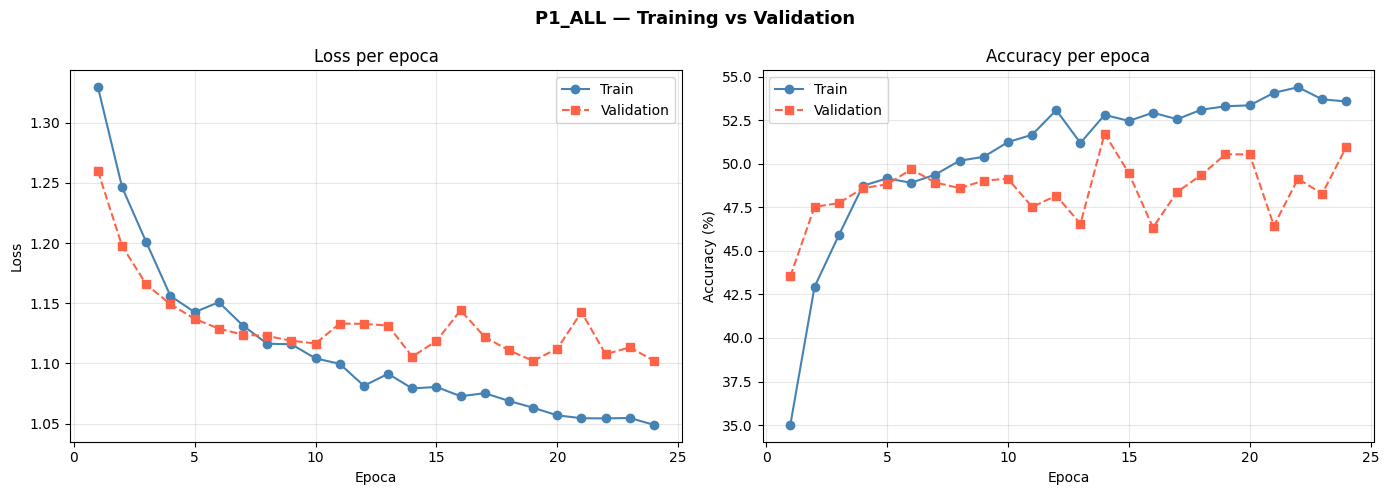

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_all/P1_ALL_storia.png

── Valutazione finale [P1_ALL] ────────────────────────────────────
  Accuracy          : 50.54%
  Balanced Accuracy : 49.36%

  Classification Report :
              precision    recall  f1-score   support

     autunno       0.51      0.54      0.53       275
      estate       0.44      0.55      0.49       186
     inverno       0.57      0.63      0.60       264
   primavera       0.46      0.25      0.32       203

    accuracy                           0.51       928
   macro avg       0.50      0.49      0.48       928
weighted avg       0.50      0.51      0.49       928



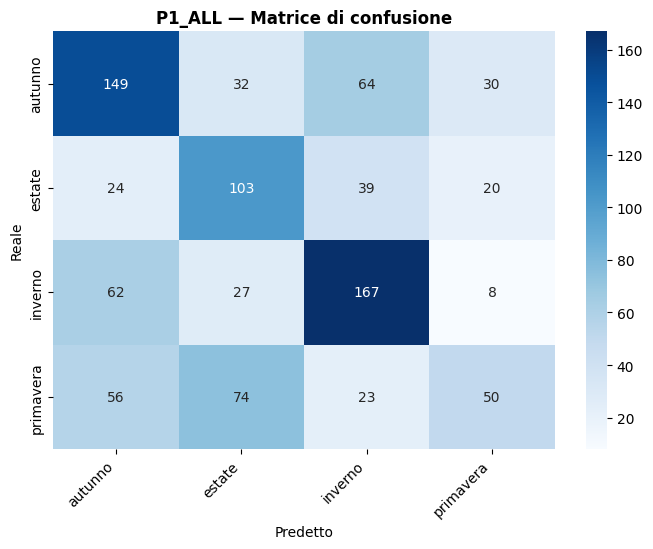

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_all/P1_ALL_confusione.png
  💾 Modello → /content/drive/MyDrive/progetto/risultati_all/P1_ALL_modello.pth


In [27]:
# ── Passo 5A · PARTE 1 · 4 stagioni · tutti i dati ──────────────────────────
train_ds_a1 = Dataset4Classi(TRAIN_ALL, transform=train_transform)
val_ds_a1   = Dataset4Classi(TEST_ALL,  transform=val_transform)

print(f"Classi : {train_ds_a1.classes}")
print(f"Train  : {len(train_ds_a1)} img   |   Val : {len(val_ds_a1)} img")

# Verifica distribuzione per classe
for c, i in train_ds_a1.class_to_idx.items():
    n = sum(1 for _, l in train_ds_a1.samples if l == i)
    print(f"  {c:<12} → {n} immagini")

model_a1, history_a1, y_true_a1, y_pred_a1, cn_a1 = run_experiment(
    tag        = "P1_ALL",
    train_ds   = train_ds_a1,
    val_ds     = val_ds_a1,
    output_dir = OUTPUT_ALL,
)

In [28]:
#model_a1, history_a1, y_true_a1, y_pred_a1, cn_a1 = run_experiment(
   # tag        = "P1_ALL",
   # train_ds   = train_ds_a1,
   # val_ds     = val_ds_a1,
   # output_dir = OUTPUT_ALL,
#)


---
## Passo 6A — PARTE 2 · 12 sotto-tipi · tutti i dati

> ⚠️ **Un unico modello** su tutte le 12 classi — non 4 addestramenti separati.

| Stagione  | Sotto-tipi            |
|-----------|-----------------------|
| autunno   | deep · soft · warm    |
| estate    | cool · soft · light   |
| inverno   | bright · cool · deep  |
| primavera | bright · light · warm |

Struttura cartelle attesa :
```
RGB/train/autunno/deep/   → autunno_deep
RGB/train/autunno/soft/   → autunno_soft
...
RGB/train/primavera/warm/ → primavera_warm
```


In [29]:
train_ds_a2 = Dataset12Classi(TRAIN_ALL, transform=train_transform)
val_ds_a2   = Dataset12Classi(TEST_ALL,  transform=val_transform)

print(f"Classi ({len(train_ds_a2.classes)}) :")
for c in train_ds_a2.classes: print(f"  {c}")
print(f"Train : {len(train_ds_a2)} img   |   Val : {len(val_ds_a2)} img")


Classi (12) :
  autunno_deep
  autunno_soft
  autunno_warm
  estate_cool
  estate_light
  estate_soft
  inverno_bright
  inverno_cool
  inverno_deep
  primavera_bright
  primavera_light
  primavera_warm
Train : 4030 img   |   Val : 928 img



  P2_ALL  |  12 classi
  Train : 4030 img   |   Val : 928 img
  Ep [01/30] | Train  Loss:2.4437  Acc:13.77% | Val    Loss:2.3642  Acc:19.07%
  Ep [02/30] | Train  Loss:2.3320  Acc:18.86% | Val    Loss:2.2784  Acc:19.18%
  Ep [03/30] | Train  Loss:2.2554  Acc:21.49% | Val    Loss:2.2159  Acc:20.58%
  Ep [04/30] | Train  Loss:2.1822  Acc:23.33% | Val    Loss:2.1898  Acc:19.40%
  Ep [05/30] | Train  Loss:2.1449  Acc:24.57% | Val    Loss:2.1515  Acc:22.41%
  Ep [06/30] | Train  Loss:2.0981  Acc:27.44% | Val    Loss:2.1299  Acc:23.81%
  Ep [07/30] | Train  Loss:2.0821  Acc:26.97% | Val    Loss:2.1106  Acc:23.60%
  Ep [08/30] | Train  Loss:2.0581  Acc:28.34% | Val    Loss:2.1041  Acc:23.60%
  Ep [09/30] | Train  Loss:2.0391  Acc:28.61% | Val    Loss:2.0909  Acc:23.28%
  Ep [10/30] | Train  Loss:2.0156  Acc:29.70% | Val    Loss:2.0910  Acc:23.60%
  Ep [11/30] | Train  Loss:2.0086  Acc:29.45% | Val    Loss:2.0762  Acc:26.19%
  Ep [12/30] | Train  Loss:1.9932  Acc:30.00% | Val    Loss:2.0880  

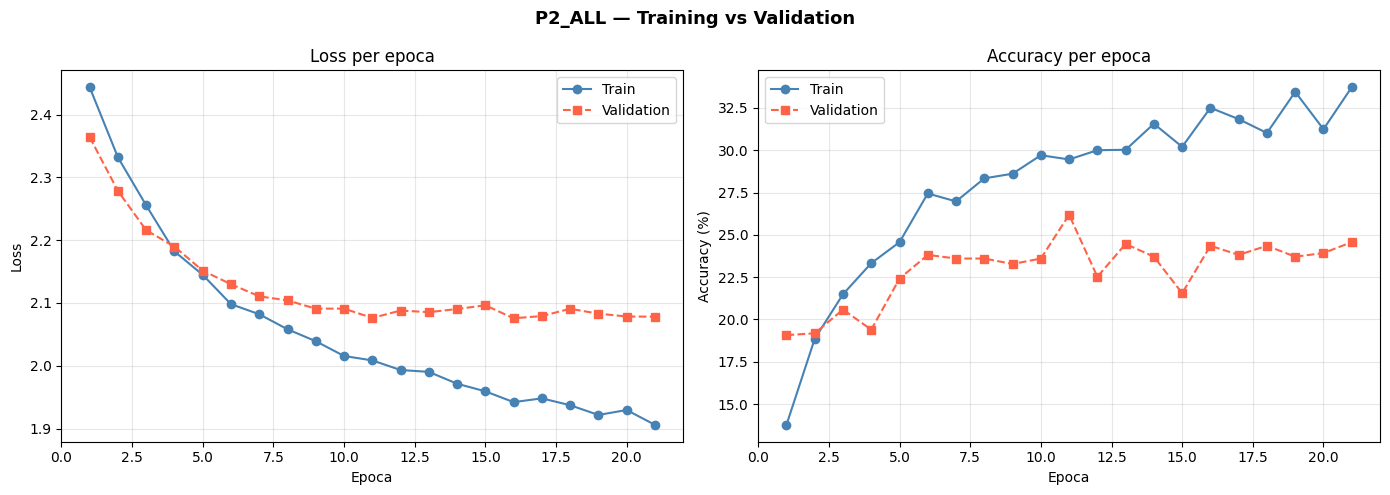

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_all/P2_ALL_storia.png

── Valutazione finale [P2_ALL] ────────────────────────────────────
  Accuracy          : 24.35%
  Balanced Accuracy : 21.12%

  Classification Report :
                  precision    recall  f1-score   support

    autunno_deep       0.29      0.40      0.34       112
    autunno_soft       0.11      0.10      0.10        73
    autunno_warm       0.37      0.19      0.25        90
     estate_cool       0.16      0.09      0.12        53
    estate_light       0.36      0.33      0.34        70
     estate_soft       0.07      0.21      0.11        63
  inverno_bright       0.21      0.05      0.08        58
    inverno_cool       0.33      0.20      0.25        89
    inverno_deep       0.32      0.59      0.41       117
primavera_bright       0.17      0.02      0.03        66
 primavera_light       0.26      0.14      0.18        64
  primavera_warm       0.25      0.22      0.23        73

        accu

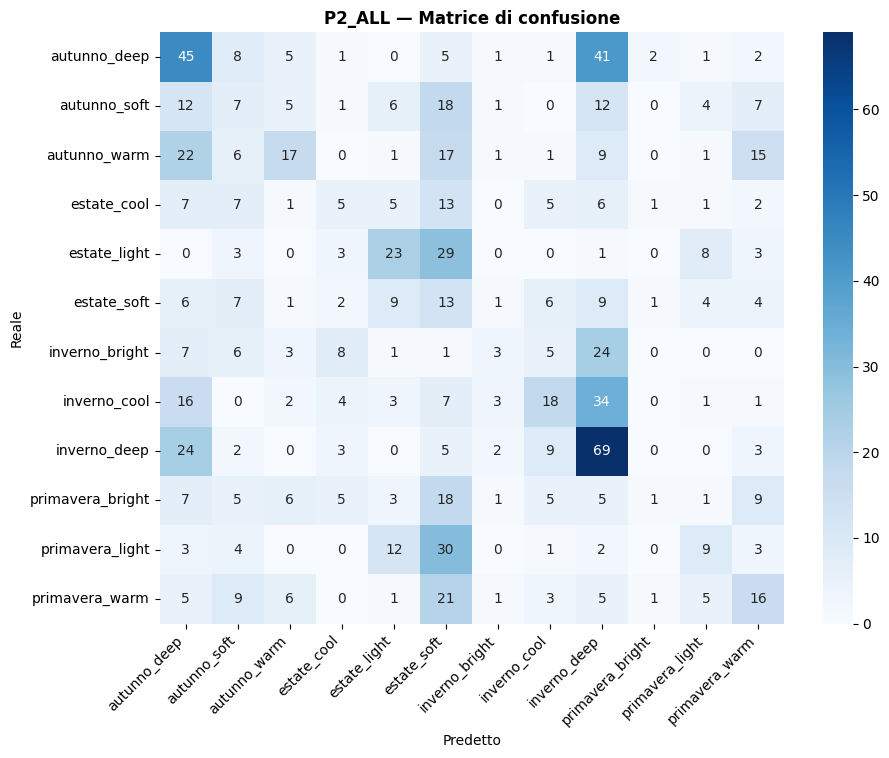

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_all/P2_ALL_confusione.png
  💾 Modello → /content/drive/MyDrive/progetto/risultati_all/P2_ALL_modello.pth


In [30]:
model_a2, history_a2, y_true_a2, y_pred_a2, cn_a2 = run_experiment(
    tag        = "P2_ALL",
    train_ds   = train_ds_a2,
    val_ds     = val_ds_a2,
    output_dir = OUTPUT_ALL,
)


---
# 🅑 SEZIONE B — NO-MAKEUP ONLY

> **Stessa cartella Drive di Sezione A** (`TRAIN_ALL` / `TEST_ALL`).  
> Il filtro no-makeup è applicato direttamente al momento del caricamento  
> tramite i set `NM_TRAIN` / `NM_TEST` costruiti dal CSV.  
> Il **train/test split è identico** a quello già usato in 🅐.  
> ✅ Nessuna cartella Drive aggiuntiva richiesta.

---
## Passo 5B — PARTE 1 · 4 stagioni · no-makeup


In [34]:
df_nm = pd.read_csv(CSV_NM)

print("Colonne CSV:", df_nm.columns.tolist())
print("Valori in 'partition':", df_nm['partition'].unique())
print("Totale righe:", len(df_nm))
print("\nPrime 3 righe:")
print(df_nm.head(3))
print("\nEsempio path_rgb_original:")
print(df_nm['path_rgb_original'].iloc[0])

Colonne CSV: ['class', 'sub_class', 'partition', 'celeba', 'path_rgb_original', 'path_rgb_masked', 'path_mask', 'filename', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
Valori in 'partition': ['train' 'test']
Totale righe: 1872

Prime 3 righe:
     class sub_class partition  celeba                 path_rgb_original  \
0  autunno      deep     train    True  RGB/train/autunno/deep/10306.jpg   
1  autunno      deep     train    True  RGB/train/autunno/deep/10

In [31]:
# Confronta nomi file su Drive vs nomi nel CSV
import os

# Prendi 5 file reali da Drive
file_drive = []
for stagione in os.listdir(TRAIN_ALL):
    s_path = os.path.join(TRAIN_ALL, stagione)
    if not os.path.isdir(s_path): continue
    for sotto in os.listdir(s_path):
        t_path = os.path.join(s_path, sotto)
        if not os.path.isdir(t_path): continue
        for fn in os.listdir(t_path)[:2]:
            file_drive.append(fn)
        if len(file_drive) >= 5:
            break
    if len(file_drive) >= 5:
        break

print("File su Drive:")
for f in file_drive:
    print(f"  '{f}'")

print("\nFile nel CSV (NM_TRAIN):")
for f in list(NM_TRAIN)[:5]:
    print(f"  '{f}'")

print("\nMatch test:")
for f in file_drive[:3]:
    print(f"  '{f}' in NM_TRAIN → {f in NM_TRAIN}")

File su Drive:
  '11708.png'
  '1044.png'
  '12284.png'
  '11693.png'
  '10396.png'
  '10284.png'

File nel CSV (NM_TRAIN):
  '948.png'
  '28302.png'
  '14305.png'
  '9757.png'
  '24975.png'

Match test:
  '11708.png' in NM_TRAIN → True
  '1044.png' in NM_TRAIN → True
  '12284.png' in NM_TRAIN → True


In [32]:
numeri = 0
celebrity = 0
esempi_celebrity = []
esempi_numeri = []

for stagione in os.listdir(TRAIN_ALL):
    s_path = os.path.join(TRAIN_ALL, stagione)
    if not os.path.isdir(s_path): continue
    for sotto in os.listdir(s_path):
        t_path = os.path.join(s_path, sotto)
        if not os.path.isdir(t_path): continue
        for fn in os.listdir(t_path):
            if not fn.lower().endswith(('.jpg','.jpeg','.png')): continue
            # Controlla se il nome è numerico (es. 010306.jpg)
            nome_senza_ext = os.path.splitext(fn)[0]
            if nome_senza_ext.isdigit():
                numeri += 1
                if len(esempi_numeri) < 3:
                    esempi_numeri.append(fn)
            else:
                celebrity += 1
                if len(esempi_celebrity) < 3:
                    esempi_celebrity.append(fn)

print(f"File numerici (CelebA) : {numeri}")
print(f"File celebrity         : {celebrity}")
print(f"\nEsempi numerici  : {esempi_numeri}")
print(f"Esempi celebrity : {esempi_celebrity}")

File numerici (CelebA) : 2069
File celebrity         : 1961

Esempi numerici  : ['11708.png', '1044.png', '11634.png']
Esempi celebrity : ['Anna Valle6.png', 'ANNE HATHAWAY 1.png', 'anne hathaway12.png']


Classi : ['autunno', 'estate', 'inverno', 'primavera']
Train  : 1284 img no-makeup   |   Val : 588 img no-makeup
  autunno      → 342 immagini no-makeup
  estate       → 290 immagini no-makeup
  inverno      → 373 immagini no-makeup
  primavera    → 279 immagini no-makeup
✅ Dataset no-makeup caricati correttamente.

  P1_NM  |  4 classi
  Train : 1284 img   |   Val : 588 img
  Ep [01/30] | Train  Loss:1.3679  Acc:29.83% | Val    Loss:1.3331  Acc:37.93%
  Ep [02/30] | Train  Loss:1.3143  Acc:35.83% | Val    Loss:1.2900  Acc:39.97%
  Ep [03/30] | Train  Loss:1.2700  Acc:39.33% | Val    Loss:1.2609  Acc:40.65%
  Ep [04/30] | Train  Loss:1.2394  Acc:42.21% | Val    Loss:1.2225  Acc:47.11%
  Ep [05/30] | Train  Loss:1.2158  Acc:43.30% | Val    Loss:1.2101  Acc:45.75%
  Ep [06/30] | Train  Loss:1.2059  Acc:46.11% | Val    Loss:1.2159  Acc:43.71%
  Ep [07/30] | Train  Loss:1.1938  Acc:45.87% | Val    Loss:1.1985  Acc:44.73%
  Ep [08/30] | Train  Loss:1.1600  Acc:48.60% | Val    Loss:1.1747  A

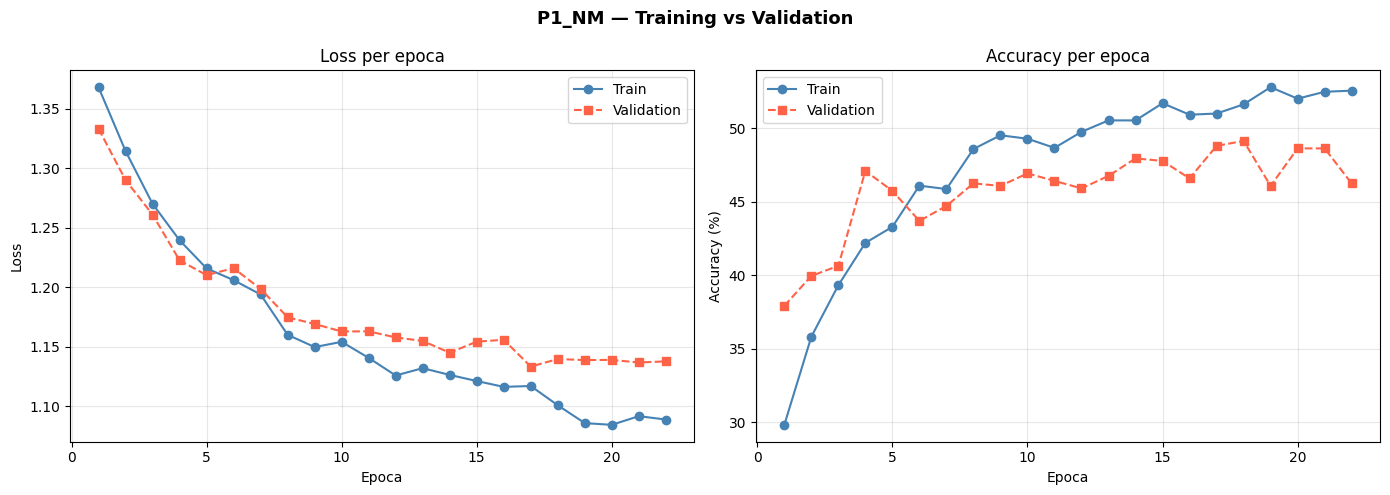

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_nomakeup/P1_NM_storia.png

── Valutazione finale [P1_NM] ────────────────────────────────────
  Accuracy          : 48.81%
  Balanced Accuracy : 47.64%

  Classification Report :
              precision    recall  f1-score   support

     autunno       0.56      0.48      0.52       184
      estate       0.39      0.38      0.39       118
     inverno       0.54      0.64      0.59       160
   primavera       0.41      0.40      0.40       126

    accuracy                           0.49       588
   macro avg       0.47      0.48      0.47       588
weighted avg       0.49      0.49      0.49       588



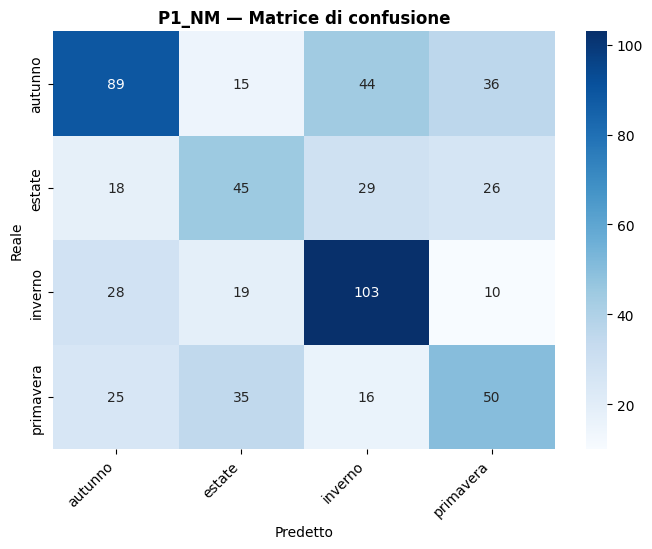

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_nomakeup/P1_NM_confusione.png
  💾 Modello → /content/drive/MyDrive/progetto/risultati_nomakeup/P1_NM_modello.pth


In [33]:
# ── Passo 5B · PARTE 1 · 4 stagioni · no-makeup ─────────────────────────────
train_ds_b1 = Dataset4Classi_NM(TRAIN_ALL, nm_files=NM_TRAIN, transform=train_transform)
val_ds_b1   = Dataset4Classi_NM(TEST_ALL,  nm_files=NM_TEST,  transform=val_transform)

print(f"Classi : {train_ds_b1.classes}")
print(f"Train  : {len(train_ds_b1)} img no-makeup   |   Val : {len(val_ds_b1)} img no-makeup")

for c, i in train_ds_b1.class_to_idx.items():
    n = sum(1 for _, l in train_ds_b1.samples if l == i)
    print(f"  {c:<12} → {n} immagini no-makeup")

assert len(train_ds_b1) > 0, "❌ train_ds_b1 vuoto! Controllare CSV_NM e TRAIN_ALL."
assert len(val_ds_b1)   > 0, "❌ val_ds_b1 vuoto!   Controllare CSV_NM e TEST_ALL."
print("✅ Dataset no-makeup caricati correttamente.")

model_b1, history_b1, y_true_b1, y_pred_b1, cn_b1 = run_experiment(
    tag        = "P1_NM",
    train_ds   = train_ds_b1,
    val_ds     = val_ds_b1,
    output_dir = OUTPUT_NM,
)

---
## Passo 6B — PARTE 2 · 12 sotto-tipi · no-makeup

> ⚠️ **Un unico modello** — même logique que 6A, chemin no-makeup.


In [35]:
train_ds_b2 = Dataset12Classi_NM(TRAIN_ALL, nm_files=NM_TRAIN, transform=train_transform)
val_ds_b2   = Dataset12Classi_NM(TEST_ALL,  nm_files=NM_TEST,  transform=val_transform)

print(f"Classi ({len(train_ds_b2.classes)}) :")
for c in train_ds_b2.classes: print(f"  {c}")
print(f"Train : {len(train_ds_b2)} img no-makeup   |   Val : {len(val_ds_b2)} img no-makeup")

# Sanity check
assert len(train_ds_b2) > 0, "❌ train_ds_b2 vuoto! Controllare CSV_NM e TRAIN_ALL."
assert len(val_ds_b2)   > 0, "❌ val_ds_b2 vuoto!   Controllare CSV_NM e TEST_ALL."
print("✅ Dataset 12 classi no-makeup caricati correttamente.")


Classi (12) :
  autunno_deep
  autunno_soft
  autunno_warm
  estate_cool
  estate_light
  estate_soft
  inverno_bright
  inverno_cool
  inverno_deep
  primavera_bright
  primavera_light
  primavera_warm
Train : 1284 img no-makeup   |   Val : 588 img no-makeup
✅ Dataset 12 classi no-makeup caricati correttamente.



  P2_NM  |  12 classi
  Train : 1284 img   |   Val : 588 img
  Ep [01/30] | Train  Loss:2.4831  Acc:9.19% | Val    Loss:2.4140  Acc:11.56%
  Ep [02/30] | Train  Loss:2.4111  Acc:15.34% | Val    Loss:2.3737  Acc:14.29%
  Ep [03/30] | Train  Loss:2.3781  Acc:15.89% | Val    Loss:2.3415  Acc:17.52%
  Ep [04/30] | Train  Loss:2.3251  Acc:18.30% | Val    Loss:2.3052  Acc:17.52%
  Ep [05/30] | Train  Loss:2.2866  Acc:20.48% | Val    Loss:2.2775  Acc:22.79%
  Ep [06/30] | Train  Loss:2.2573  Acc:20.95% | Val    Loss:2.2520  Acc:21.43%
  Ep [07/30] | Train  Loss:2.2559  Acc:21.65% | Val    Loss:2.2331  Acc:21.43%
  Ep [08/30] | Train  Loss:2.2117  Acc:24.61% | Val    Loss:2.2152  Acc:22.45%
  Ep [09/30] | Train  Loss:2.1816  Acc:24.14% | Val    Loss:2.2061  Acc:21.94%
  Ep [10/30] | Train  Loss:2.1757  Acc:24.84% | Val    Loss:2.1952  Acc:22.62%
  Ep [11/30] | Train  Loss:2.1362  Acc:26.17% | Val    Loss:2.1759  Acc:24.15%
  Ep [12/30] | Train  Loss:2.1330  Acc:26.01% | Val    Loss:2.1743  Ac

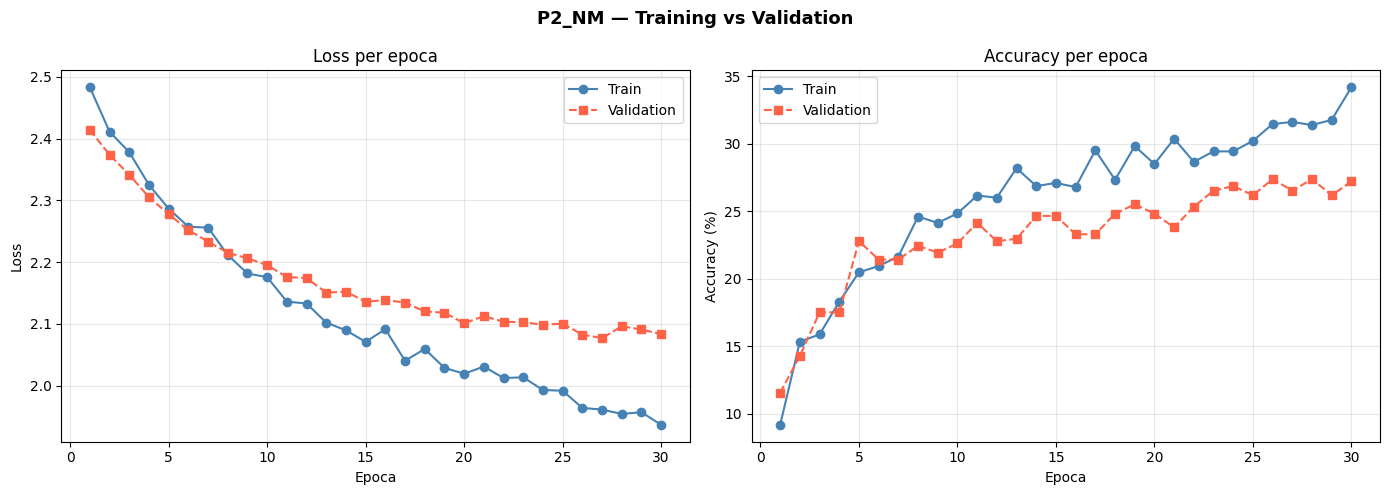

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_nomakeup/P2_NM_storia.png

── Valutazione finale [P2_NM] ────────────────────────────────────
  Accuracy          : 26.53%
  Balanced Accuracy : 23.47%

  Classification Report :
                  precision    recall  f1-score   support

    autunno_deep       0.38      0.45      0.41        80
    autunno_soft       0.15      0.08      0.10        53
    autunno_warm       0.48      0.20      0.28        51
     estate_cool       0.10      0.15      0.12        34
    estate_light       0.38      0.31      0.34        45
     estate_soft       0.06      0.03      0.04        39
  inverno_bright       0.00      0.00      0.00        37
    inverno_cool       0.17      0.27      0.21        52
    inverno_deep       0.27      0.55      0.36        71
primavera_bright       0.08      0.02      0.04        43
 primavera_light       0.34      0.48      0.40        42
  primavera_warm       0.26      0.29      0.27        41

        a

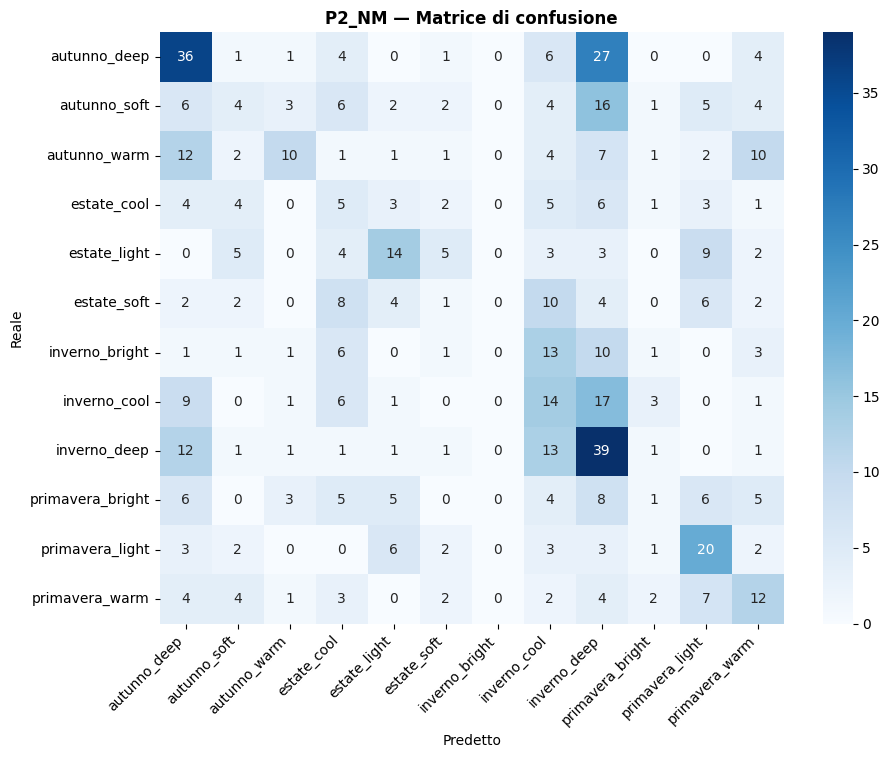

  💾 Salvato → /content/drive/MyDrive/progetto/risultati_nomakeup/P2_NM_confusione.png
  💾 Modello → /content/drive/MyDrive/progetto/risultati_nomakeup/P2_NM_modello.pth


In [37]:
model_b2, history_b2, y_true_b2, y_pred_b2, cn_b2 = run_experiment(
    tag        = "P2_NM",
    train_ds   = train_ds_b2,
    val_ds     = val_ds_b2,
    output_dir = OUTPUT_NM,
)


---
## Passo 7 — Riepilogo comparativo

In [38]:
print("=" * 72)
print("  RIEPILOGO COMPARATIVO")
print("=" * 72)
print(f"  {'Esperimento':<42} {'Acc':>8}  {'Bal.Acc':>8}  {'Epoche':>7}")
print("  " + "-" * 70)

results = [
    ("PARTE 1 · ALL DATA    (4 stagioni)",    history_a1, y_true_a1, y_pred_a1),
    ("PARTE 2 · ALL DATA    (12 sotto-tipi)", history_a2, y_true_a2, y_pred_a2),
    ("PARTE 1 · NO-MAKEUP   (4 stagioni)",    history_b1, y_true_b1, y_pred_b1),
    ("PARTE 2 · NO-MAKEUP   (12 sotto-tipi)", history_b2, y_true_b2, y_pred_b2),
]

for nome, hist, yt, yp in results:
    acc  = accuracy_score(yt, yp) * 100
    bacc = balanced_accuracy_score(yt, yp) * 100
    ep   = len(hist["train_loss"])
    print(f"  {nome:<42} {acc:>7.2f}%  {bacc:>7.2f}%  {ep:>7}")

print()
print(f"  📁 Risultati ALL DATA  → {OUTPUT_ALL}")
print(f"  📁 Risultati NO-MAKEUP → {OUTPUT_NM}")


  RIEPILOGO COMPARATIVO
  Esperimento                                     Acc   Bal.Acc   Epoche
  ----------------------------------------------------------------------
  PARTE 1 · ALL DATA    (4 stagioni)           50.54%    49.36%       24
  PARTE 2 · ALL DATA    (12 sotto-tipi)        24.35%    21.12%       21
  PARTE 1 · NO-MAKEUP   (4 stagioni)           48.81%    47.64%       22
  PARTE 2 · NO-MAKEUP   (12 sotto-tipi)        26.53%    23.47%       30

  📁 Risultati ALL DATA  → /content/drive/MyDrive/progetto/risultati_all
  📁 Risultati NO-MAKEUP → /content/drive/MyDrive/progetto/risultati_nomakeup
